# 03 · Linear Regression from Scratch

Regression predicts a **continuous number** (a price, a temperature, a risk score). Linear
regression is the simplest useful model *and* the clearest window into how ML works, because
you can derive it two ways and see them agree:

1. **Closed form (Ordinary Least Squares)** — a single matrix formula.
2. **Gradient descent** — the iterative engine from notebook 02.

Then we'll meet the two ideas that haunt *every* model: the **bias–variance trade-off** and
its cure, **regularization**. We build everything ourselves, then confirm it matches
scikit-learn.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1. Make some data with a known answer

We generate `y = 4 + 3x + noise`. Because we *chose* the true slope (3) and intercept (4),
we can check whether our model recovers them.

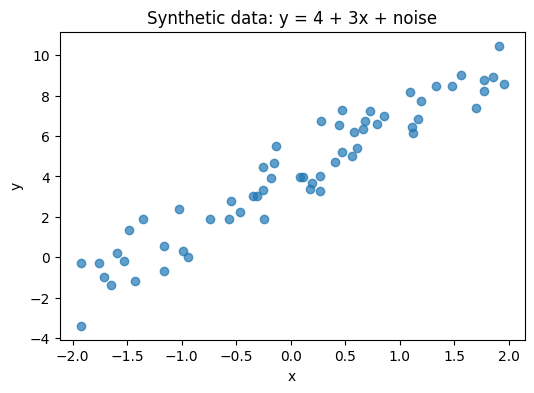

In [2]:
n = 60
X = np.random.uniform(-2, 2, size=(n, 1))
true_w, true_b = 3.0, 4.0
y = true_b + true_w * X[:, 0] + np.random.normal(0, 1.0, size=n)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], y, alpha=0.7)
plt.title("Synthetic data: y = 4 + 3x + noise")
plt.xlabel("x"); plt.ylabel("y"); plt.show()

## 2. Closed form: Ordinary Least Squares (OLS)

Least squares chooses weights that minimize the summed squared errors. There's an exact
solution: with a design matrix `X_b` (features plus a column of 1s for the intercept),
`w = (Xᵀ X)⁻¹ Xᵀ y`. This is the entire model in one line of linear algebra.

> This same formula is what MLE gives you when you assume the noise is Gaussian — the link
> from notebook 02, made concrete.

In [3]:
# Add a bias column of ones so the intercept is learned like any other weight
X_b = np.c_[np.ones((n, 1)), X]                 # shape (n, 2)
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # the normal equations

print(f"intercept (true 4.0): {w_ols[0]:.3f}")
print(f"slope     (true 3.0): {w_ols[1]:.3f}")

intercept (true 4.0): 4.049
slope     (true 3.0): 2.820


## 3. Gradient descent: the same answer, learned step by step

When `Xᵀ X` is too big to invert (millions of features) we iterate instead. The gradient of
the mean squared error w.r.t. the weights is `(2/n) · Xᵀ (X_b w − y)`. We step downhill and
watch the loss fall.

GD intercept: 4.049   GD slope: 2.820
OLS matched:  True


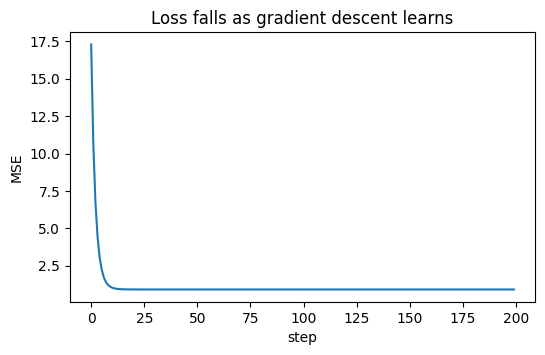

In [4]:
def mse(Xb, y, w):
    err = Xb @ w - y
    return (err @ err) / len(y)

w = np.zeros(2)          # start at zero
lr = 0.1
losses = []
for step in range(200):
    grad = (2 / n) * X_b.T @ (X_b @ w - y)
    w = w - lr * grad
    losses.append(mse(X_b, y, w))

print(f"GD intercept: {w[0]:.3f}   GD slope: {w[1]:.3f}")
print(f"OLS matched:  {np.allclose(w, w_ols, atol=1e-2)}")

plt.figure(figsize=(6, 3.5))
plt.plot(losses); plt.title("Loss falls as gradient descent learns")
plt.xlabel("step"); plt.ylabel("MSE"); plt.show()

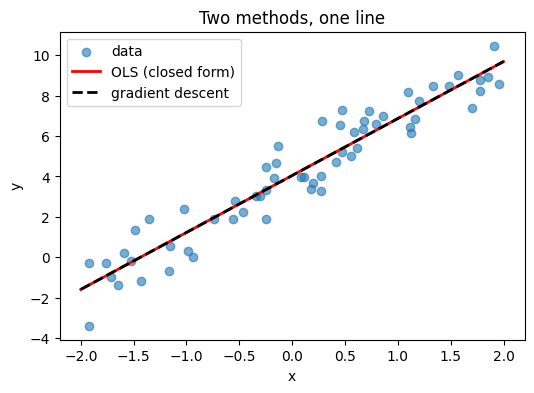

In [5]:
# Plot both fits over the data (they overlap — same line)
grid = np.linspace(-2, 2, 100)
grid_b = np.c_[np.ones(100), grid]
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], y, alpha=0.6, label="data")
plt.plot(grid, grid_b @ w_ols, 'r-', lw=2, label="OLS (closed form)")
plt.plot(grid, grid_b @ w, 'k--', lw=2, label="gradient descent")
plt.legend(); plt.title("Two methods, one line"); plt.xlabel("x"); plt.ylabel("y"); plt.show()

## 4. The bias–variance trade-off

Fit too *simple* a model and it **underfits** (high bias) — it can't capture the pattern.
Fit too *complex* a model and it **overfits** (high variance) — it memorizes the noise and
fails on new data. The art of ML is landing between them.

We show this with polynomial regression: fitting curves of increasing degree to wiggly data.

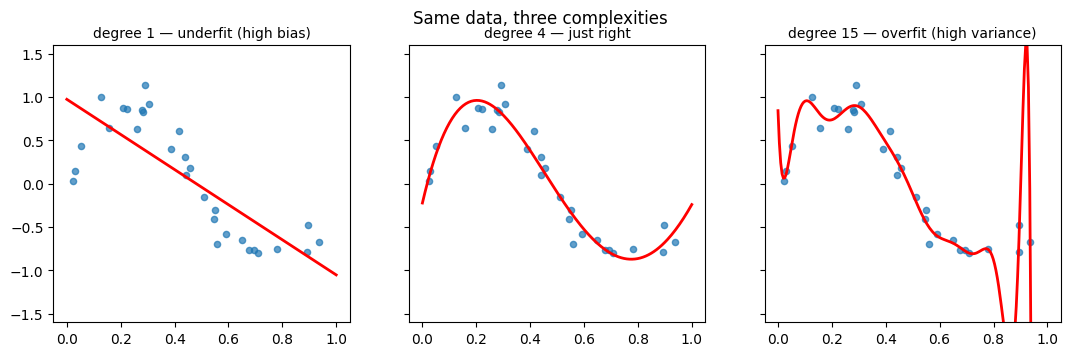

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Wiggly ground truth
rng = np.random.RandomState(3)
xt = np.sort(rng.uniform(0, 1, 30))
yt = np.sin(2 * np.pi * xt) + rng.normal(0, 0.15, size=30)
xt = xt.reshape(-1, 1)
xgrid = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, degree in zip(axes, [1, 4, 15]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(xt, yt)
    ax.scatter(xt, yt, s=20, alpha=0.7)
    ax.plot(xgrid, model.predict(xgrid), 'r-', lw=2)
    ax.set_ylim(-1.6, 1.6)
    label = {1: "degree 1 — underfit (high bias)",
             4: "degree 4 — just right",
             15: "degree 15 — overfit (high variance)"}[degree]
    ax.set_title(label, fontsize=10)
plt.suptitle("Same data, three complexities"); plt.show()

## 5. Regularization: penalize complexity

Regularization adds a penalty on large weights to the loss, discouraging the model from
contorting itself to fit noise. **Ridge** (L2) shrinks weights smoothly; **Lasso** (L1) can
drive some to exactly zero, doubling as feature selection. The strength is controlled by `α`.

Watch the wild degree-15 fit get tamed just by adding a Ridge penalty.

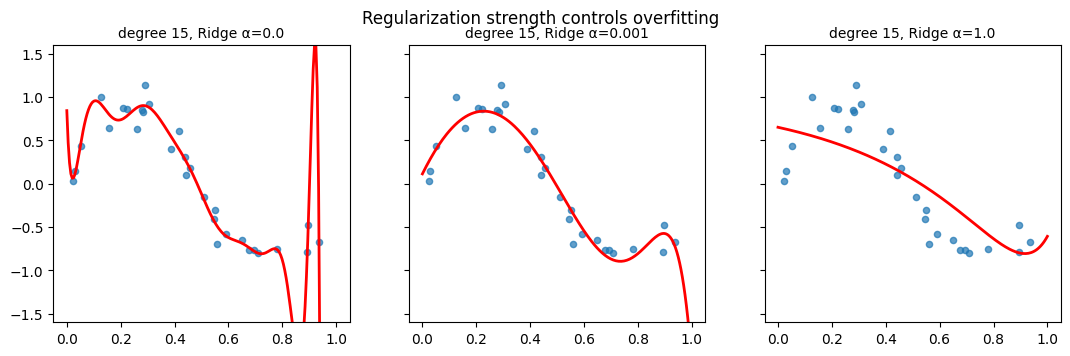

In [7]:
from sklearn.linear_model import Ridge

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, alpha in zip(axes, [0.0, 1e-3, 1.0]):
    est = Ridge(alpha=alpha) if alpha > 0 else LinearRegression()
    model = make_pipeline(PolynomialFeatures(15), est).fit(xt, yt)
    ax.scatter(xt, yt, s=20, alpha=0.7)
    ax.plot(xgrid, model.predict(xgrid), 'r-', lw=2)
    ax.set_ylim(-1.6, 1.6)
    ax.set_title(f"degree 15, Ridge α={alpha}", fontsize=10)
plt.suptitle("Regularization strength controls overfitting"); plt.show()

## Recap

- Linear regression has a **closed form** (`(XᵀX)⁻¹Xᵀy`) and a **gradient-descent** form;
  they agree.
- Assuming Gaussian noise, least squares *is* maximum likelihood.
- **Bias–variance**: too simple underfits, too complex overfits.
- **Regularization** (Ridge/Lasso) penalizes complexity; `α` is the dial.

**Next:** `04 — Linear Classifiers from Scratch` — logistic regression and naive Bayes.